In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *
from datasets.process import *

In [3]:
import os
import sys
sys.path.append(os.path.abspath("conditional-flow-matching"))
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

In [4]:
import random
import umap
from models.modules import *

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
from scripts.run_model import *

In [7]:
%reload_ext autoreload
%autoreload 2

In [8]:
############################################################

In [9]:
from torchdyn.datasets import generate_moons

from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *

In [10]:
from simulate.simulate import *
from simulate.s import *
from simulate.sphere import *

In [11]:
torch.manual_seed(42)
np.random.seed(42)

In [12]:
### SETTINGS ###

#TODO: scale up dimension
#TODO: add noise back to the sampling procedure
#TODO: calculate geodesic disparity

dataname = "sphere"
normalize = False
energy_only = False
# size = 5000
# d = 3 #dummy dimension
size = 20000
d = 20

In [13]:
############################################################

In [14]:
dic = {"sphere": process_sphere_data,
       "cylinder": process_cylinder_data,
       "ellipse": process_ellipse_data}
adata, values, fs = dic[dataname](size, d, normalize)

In [15]:
conditions, dataset = extract_dataset(adata, values)

In [16]:
############################################################

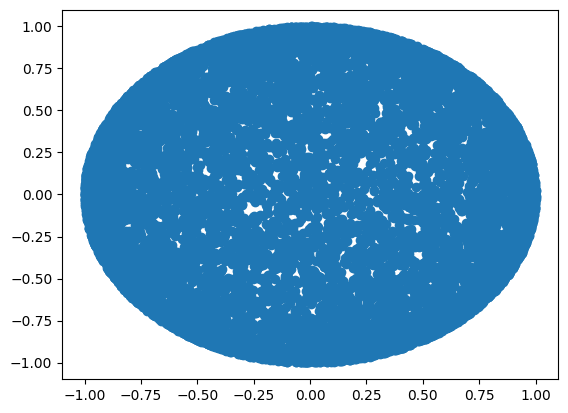

In [17]:
raw_samples = torch.from_numpy(adata.obsm['X_pca_raw']).float()
fig, ax = plt.subplots()
ax.scatter(raw_samples[:,0], raw_samples[:, 1])
plt.show()

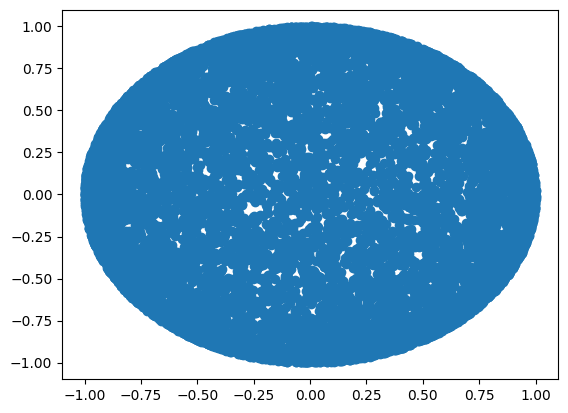

In [18]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, ax = plt.subplots()
ax.scatter(samples[:,0], samples[:, 1])
plt.show()

In [19]:
config = Config(
    {        
        "model_class": "metricflow",
        "score_max_epochs": 2000,
        "energy_max_epochs": 4000,
        "metric_max_epochs": 2,
        "embed_max_epochs": 2 if energy_only else 4000,
        "flow_max_epochs": 2 if energy_only else 2,
        "lr": 1e-4,
        "dropout": 0.0,
        "pc_dim": d,
        "cond_dim": d,
        "hidden_dim": 256,
        "score_batch_size": 4096,
        "flow_batch_size": 256,
        "num_freq": 32,
        "num_layers": 4,
        "force_cpu": False,
        "gradient_clip_val": 0,
        "loader_batch_size": 6,
        "warmup_steps": 0,
        "ema_decay": 1-1e-3,

        "mfm_benchmark": False,

        "pita_steps": 1,

        "score_alpha": 1.0,

        "energy_noise_sigma": 0.0,
        "metric_scale": 10,
        "metric_sigma": 0.05,

        "ot_in_embed": False, #embed will train over arbitrary paths, not just OT paths
        "fast_ot": False,

        "num_sigmas": 20,
        "sigma_min": 0.005,
        "sigma_max": 0.2,

        "sigma_dim": 32,

        "score_beta_min": 1.0,
        "score_beta_max": 1.0,
        
        "latent_dim": 100,

        "skip": False,
        "rescale": 0.5,

        "pre_low_q": .05,
        "pre_high_q": .98,
        "low_q": .05,
        "high_q": .95,

        "weight_beta": 1.0,

        "gamma": 0.2,

        "sigma": 0.1,

        "n_neighbors": 10,
        "resolution": 0.3,
    }
)

project = "fm-ipynb"

In [20]:
# # MFM BENCHMARK ###
# config.score_max_epochs = 2
# config.energy_max_epochs = 2
# config.metric_max_epochs = 5000
# config.mfm_benchmark = True
# config.K = 10000
# config.kappa = 0.5
# config.pita_steps = 1

In [21]:
# # MFM BENCHMARK for small d###
# config.score_max_epochs = 2
# config.energy_max_epochs = 2
# config.metric_max_epochs = 2000
# config.mfm_benchmark = True
# config.K = 1000
# config.kappa = 1.0
# config.pita_steps = 1

In [22]:
pre_score_models, pre_energy_models, score_model, energy_model, metric_model, embed_model, flow_model = run_full_model(config, project, adata, values, conditions, dataset)

/home/azweig/projects/zebrafish/datasets/process.py:82: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_train, resolution=resolution)
wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Running phase score:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type             | Params | Mode 
-----------------------------------------------------

score_pita


/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=2` reached.


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type           | Params | Mode 
--------------------------------------------------------
0 | embed_net    | SimpleEmbedNet | 226 K  | train
1 | geo_net      | SinNet         | 219 K  | train
2 | metric_model | MetricNetMFM   | 135 K  | eval 
--------------------------------------------------------
445 K     Trainable params
135 K     Non-trainable params
580 K     Total params
2.323     Total estimated model params size (MB)
32        Modules in train 

epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████
train_loss,█▂▂▁▂▂▂▂▂▂▃▂▃▂▂▃▂▃▃▃▄▃▃▄▄▂▄▂▄▄▂▃▃▅▃▃▃▃▄▄
trainer/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█
epoch,3999
train_loss,145.25244
trainer/global_step,3999


Running phase flow:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type           | Params | Mode 
-----------------------------------------------------
0 | flow_net  | SinNet         | 218 K  | train
1 | geo_net   | SinNet         | 219 K  | eval 
2 | embed_net | SimpleEmbedNet | 226 K  | eval 
-----------------------------------------------------
437 K     Trainable params
226 K     Non-trainable params
663 K     Total params
2.655     Total estimated model params size (MB)
16        Modules in train mode
32        Mod

epoch,▁█
train_loss,█▁
trainer/global_step,▁█
epoch,1
train_loss,0.03989
trainer/global_step,1


In [23]:
def visualize(model, samples):

    import matplotlib.pyplot as plt
    plt.close('all')
    m = torch.max(torch.abs(samples)).item()
    m += 1
    
    xs = torch.linspace(-m, m, steps=30)
    ys = torch.linspace(-m, m, steps=30)
    x, y = torch.meshgrid(xs, ys, indexing='xy')
    print(x.shape)
    print(y.shape)
    z = torch.stack([x, y], dim = -1).reshape(900, -1)

    zeros = torch.zeros(z.shape[0], d-2, device=z.device, dtype=z.dtype)
    z = torch.cat([z, zeros], dim=1) 

    print(z.shape)

    ###
    sigma = 0.05 * torch.ones(z.shape[0],1,device=z.device)
    # sigma = None
    ###
    v = model(z, sigma).detach()
    # h = torch.ones(z.shape[0],1).to(z.device) * min(model.score_sigma)
    # v = model(h, z).detach()

    fig, ax = plt.subplots()
    import numpy as np
    from scipy.stats import gaussian_kde
    # xy = samples.cpu().numpy().T
    # kde = gaussian_kde(xy)
    # grid = np.linspace(-m, m, 200)
    # xi, yi = np.meshgrid(grid, grid)
    # zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
    # ax.contour(xi, yi, zi, levels=10, linewidths=1)
    ax.scatter(samples[:,0], samples[:, 1])
    ax.quiver(z[:,0], z[:,1], v[:,0], v[:,1])
    plt.show()

In [24]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(score_model)
remove_all_forward_hooks(energy_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

torch.Size([30, 30])
torch.Size([30, 30])
torch.Size([900, 3])


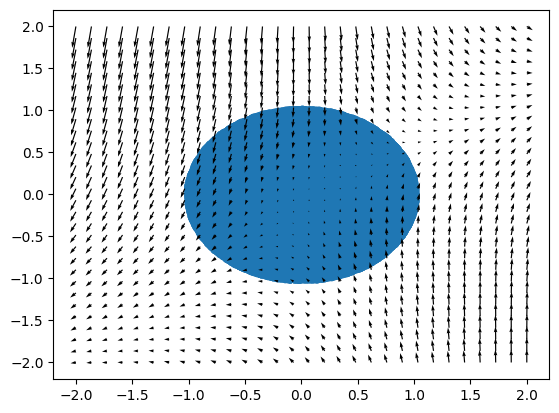

In [25]:
#SCORE VALIDATION
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize(score_model, samples)

In [26]:
def visualize_energy(energy_model, samples, grid_steps=30):

    import torch, numpy as np, matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
    plt.close('all')

    m = torch.max(torch.abs(samples)).item() + 1.0
    xs = torch.linspace(-m,  m, steps=grid_steps)
    ys = torch.linspace(-m,  m, steps=grid_steps)
    xg, yg = torch.meshgrid(xs, ys, indexing='xy')
    z   = torch.stack([xg, yg], dim=-1).reshape(-1, 2)

    zeros = torch.zeros(z.shape[0], d-2, device=z.device, dtype=z.dtype)
    z = torch.cat([z, zeros], dim=1) 

    ###
    # sigma = 0.05 * torch.ones(z.shape[0],1,device=z.device)
    # E = energy_model.forward_energy(z, sigma).detach().reshape(grid_steps, grid_steps)
    ###
    E = energy_model.get_energy(z).detach().reshape(grid_steps, grid_steps)

    fig, ax = plt.subplots()

    contour = ax.contourf(xg, yg, -E, levels=100, cmap='inferno')
    ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.005)
    ax.set_aspect('equal')
    fig.colorbar(contour, ax=ax, label="negative energy")
    plt.show()

In [27]:
def visualize_metric(metric_model, samples, grid_steps=30):

    import torch, numpy as np, matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
    plt.close('all')

    m = torch.max(torch.abs(samples)).item() + 1.0
    xs = torch.linspace(-m,  m, steps=grid_steps)
    ys = torch.linspace(-m,  m, steps=grid_steps)
    xg, yg = torch.meshgrid(xs, ys, indexing='xy')
    z   = torch.stack([xg, yg], dim=-1).reshape(-1, 2)

    zeros = torch.zeros(z.shape[0], d-2, device=z.device, dtype=z.dtype)
    z = torch.cat([z, zeros], dim=1) 

    if config.mfm_benchmark:
        E = metric_model(z.to('cuda')).detach().reshape(grid_steps, grid_steps).cpu()
    else:
        E = metric_model(z).detach().reshape(grid_steps, grid_steps)

    fig, ax = plt.subplots()

    contour = ax.contourf(xg, yg, -E, levels=100, cmap='inferno')
    ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.005)
    ax.set_aspect('equal')
    fig.colorbar(contour, ax=ax, label="negative metric tensor")
    plt.show()

In [28]:
for sm in pre_score_models:
    print(sm.score_beta)

1.0


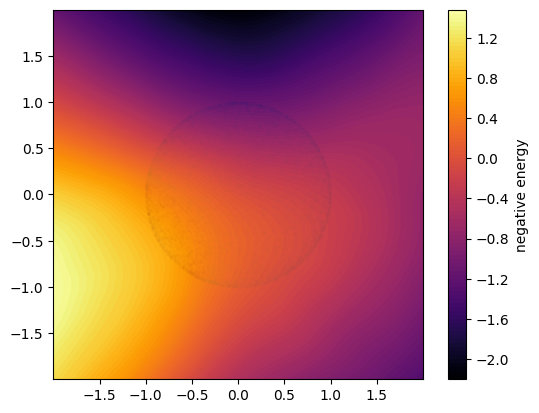

In [29]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize_energy(pre_energy_models[0], samples)

In [30]:
if len(pre_energy_models) > 1:
    samples = torch.from_numpy(adata.obsm['X_pca']).float()
    visualize_energy(pre_energy_models[1], samples)

In [31]:
if len(pre_energy_models) > 2:
    samples = torch.from_numpy(adata.obsm['X_pca']).float()
    visualize_energy(pre_energy_models[2], samples)

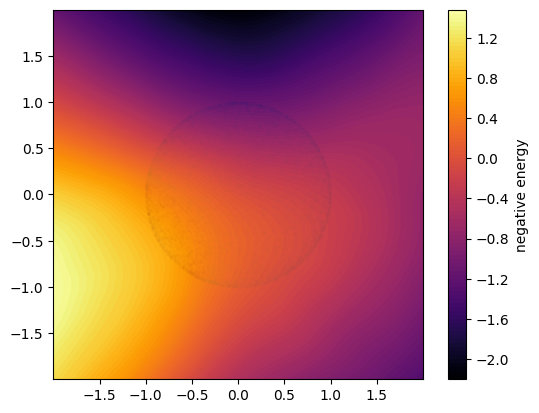

In [32]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize_energy(energy_model, samples)

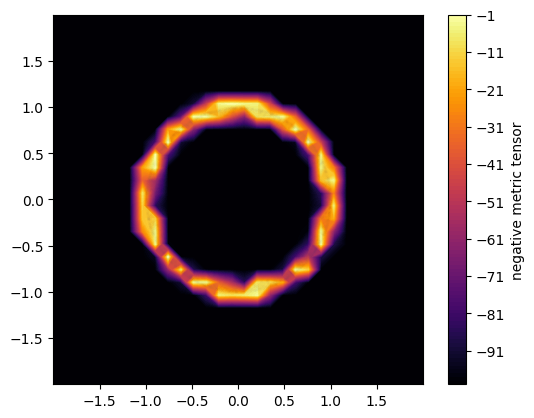

In [33]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
visualize_metric(metric_model, samples)

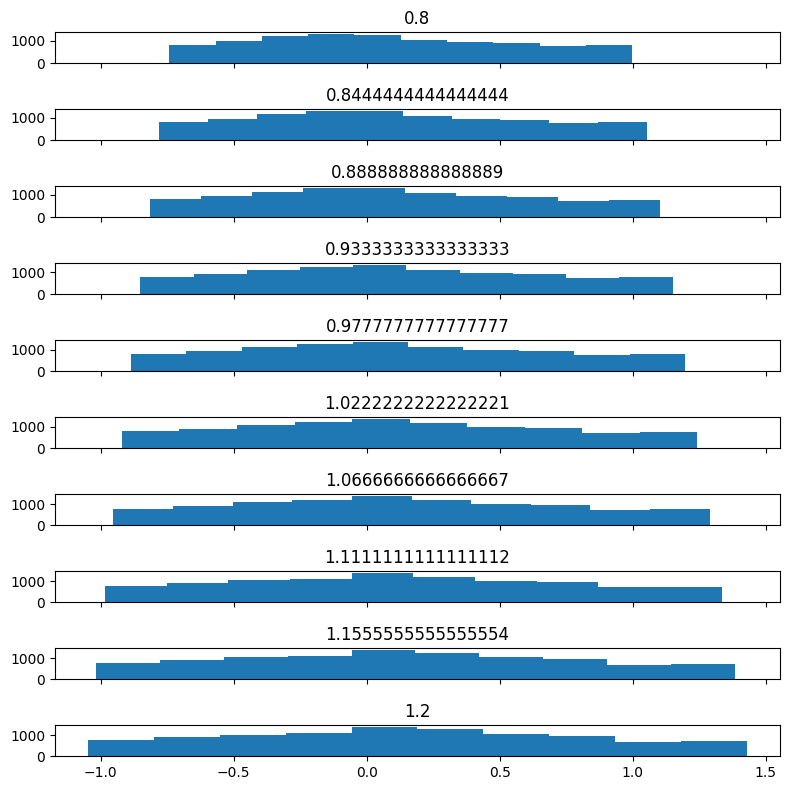

In [34]:

X = adata.obsm['X_pca']
X = torch.from_numpy(X).float()
dt = 0.2
sigmas = np.linspace(1.0-dt, 1.0+dt, 10).tolist()
fig, axs = plt.subplots(len(sigmas), figsize=(8,8), sharex=True)
for i, sigma in enumerate(sigmas):
    Z = X * sigma
    Z = Z.to(energy_model.get_device())
    E = energy_model.get_energy(Z).detach().cpu().numpy()
    axs[i].hist(E)
    axs[i].set_title(str(sigmas[i]))
plt.tight_layout()
plt.show()

In [35]:
from torch.utils.data import TensorDataset, Sampler, DataLoader
from datasets.dataset import *

_, raw_dataset = extract_dataset(adata, values, use_rep='X_pca_raw')
train_dataset = ShufflingDataset(raw_dataset, 500, conditions)
train_dataloader = DataLoader(train_dataset, batch_size = config.loader_batch_size, shuffle=True)

In [36]:
#GEO VALIDATION
if not energy_only:
    for batch in train_dataloader:

        x0, x1, _, _, _ = batch
        
        paths = embed_model.sample_geodesic(batch, points=100, ot_sample=False)
        
        break

In [37]:
paths.shape

torch.Size([100, 500, 3])

In [38]:
if d == 2:
    fig, ax = plt.subplots(5, figsize=(8,8), sharex=True, sharey=True)
    for i in range(5):
        traj = paths[:,i]
        ax[i].scatter(raw_samples[:,0], raw_samples[:, 1])
        ax[i].plot(traj[:, 0], traj[:, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
        ax[i].set(adjustable='box', aspect='equal')
    plt.show()

In [39]:
def slerp(x0: torch.Tensor, x1: torch.Tensor, t: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Calculates batched Spherical Linear Interpolation (Slerp) to find points on 
    the geodesic path on a sphere. This function is identical to the one previously provided.
    """
    # --- 1. Input Validation and Normalization ---
    x0 = F.normalize(x0, p=2, dim=-1)
    x1 = F.normalize(x1, p=2, dim=-1)

    # --- 2. Calculate the Angle (Omega) between Vectors ---
    dot_product = torch.sum(x0 * x1, dim=-1)
    dot_product = torch.clamp(dot_product, -1.0, 1.0)
    omega = torch.acos(dot_product)

    # --- 3. Handle Edge Cases and Prepare for Broadcasting ---
    sin_omega = torch.sin(omega)
    
    # Reshape for broadcasting
    t_view = t.view(-1, 1)
    omega_view = omega.view(-1, 1)
    sin_omega_view = sin_omega.view(-1, 1)

    # --- 4. Calculate Slerp Coefficients ---
    is_small_angle = sin_omega_view.abs() < eps
    
    c0_linear = 1.0 - t_view
    c1_linear = t_view
    
    c0 = torch.sin((1.0 - t_view) * omega_view) / sin_omega_view
    c1 = torch.sin(t_view * omega_view) / sin_omega_view
    
    c0 = torch.where(is_small_angle, c0_linear, c0)
    c1 = torch.where(is_small_angle, c1_linear, c1)
    
    # --- 5. Compute and Return the Interpolated Vector ---
    xt = c0 * x0 + c1 * x1
    xt = F.normalize(xt, p=2, dim=-1)
    
    return xt

In [40]:
def visualize_geodesics(x0, x1, paths, title_prefix = ""):
    """
    Creates a 3D matplotlib visualization of the geodesic paths on a sphere.

    Args:
        x0 (torch.Tensor): The batch of starting points. Shape: (batch_size, 3).
        x1 (torch.Tensor): The batch of final points. Shape: (batch_size, 3).
        paths (list[torch.Tensor]): A list where each element is a tensor of points
                                     representing a geodesic path.
    """
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # --- 1. Draw the Sphere ---
    # Create the meshgrid for the sphere's surface
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))

    # Plot the wireframe of the sphere
    ax.plot_wireframe(x, y, z, color='gray', alpha=0.2, rstride=5, cstride=5)

    # --- 2. Plot the Points and Paths ---
    # Convert tensors to numpy for plotting
    x0_np = x0.numpy()
    x1_np = x1.numpy()

    # Plot start points (blue) and end points (red)
    ax.scatter(x0_np[:, 0], x0_np[:, 1], x0_np[:, 2], c='blue', s=100, label='Start Points (x0)')
    ax.scatter(x1_np[:, 0], x1_np[:, 1], x1_np[:, 2], c='red', s=100, label='End Points (x1)')

    # Plot the geodesic paths
    for i, path in enumerate(paths):
        path_np = path.numpy()
        ax.plot(path_np[:, 0], path_np[:, 1], path_np[:, 2], color='green', 
                label=f'Path {i}' if i == 0 else "") # Only label the first path

    # --- 3. Set Plot Aesthetics ---
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')
    ax.set_title(title_prefix + " " + 'Geodesic Paths')
    
    # Set aspect ratio to be equal
    ax.set_box_aspect([1, 1, 1]) # IMPORTANT for a correct sphere visualization
    
    # Set axis limits to keep the sphere centered and properly scaled
    ax.set_xlim([-1.1, 1.1])
    ax.set_ylim([-1.1, 1.1])
    ax.set_zlim([-1.1, 1.1])
    
    ax.legend()
    plt.show()

In [41]:
path_resolution = paths.shape[0]
batch_size = paths.shape[1]

x0 = paths[0]
x1 = paths[-1]

x0 = F.normalize(x0, p=2, dim=-1)
x1 = F.normalize(x1, p=2, dim=-1)

geodesic_paths = []
for i in range(batch_size):
    t_path = torch.linspace(0, 1, path_resolution)
    
    x0_path = x0[i].expand(path_resolution, -1)
    x1_path = x1[i].expand(path_resolution, -1)
    
    # Calculate the path
    true_path = slerp(x0_path, x1_path, t_path)
    geodesic_paths.append(true_path)
    

In [42]:
paths[:,:5].shape

torch.Size([100, 5, 3])

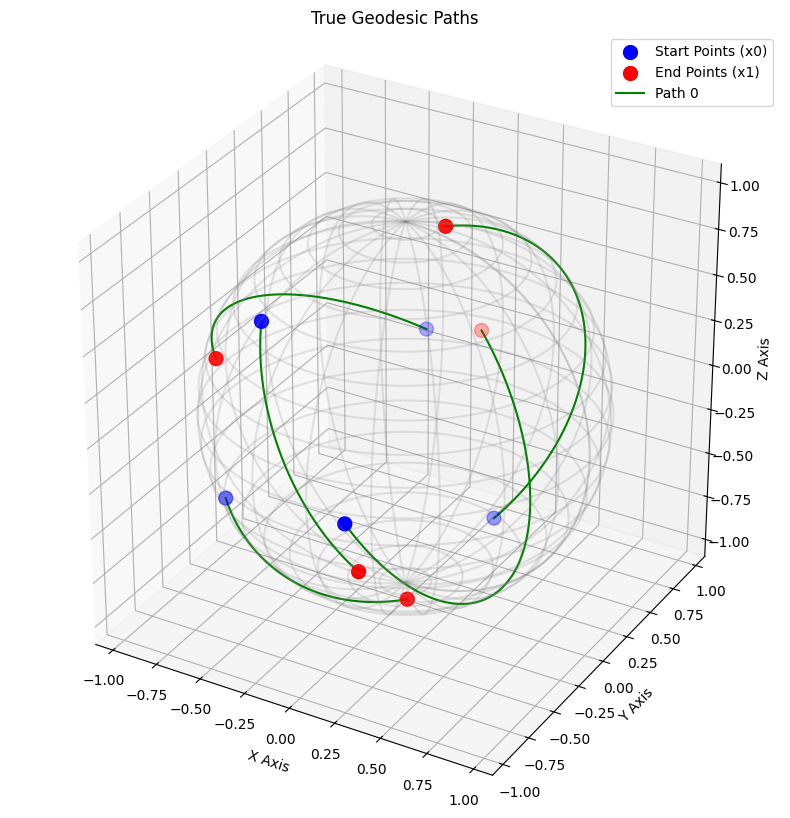

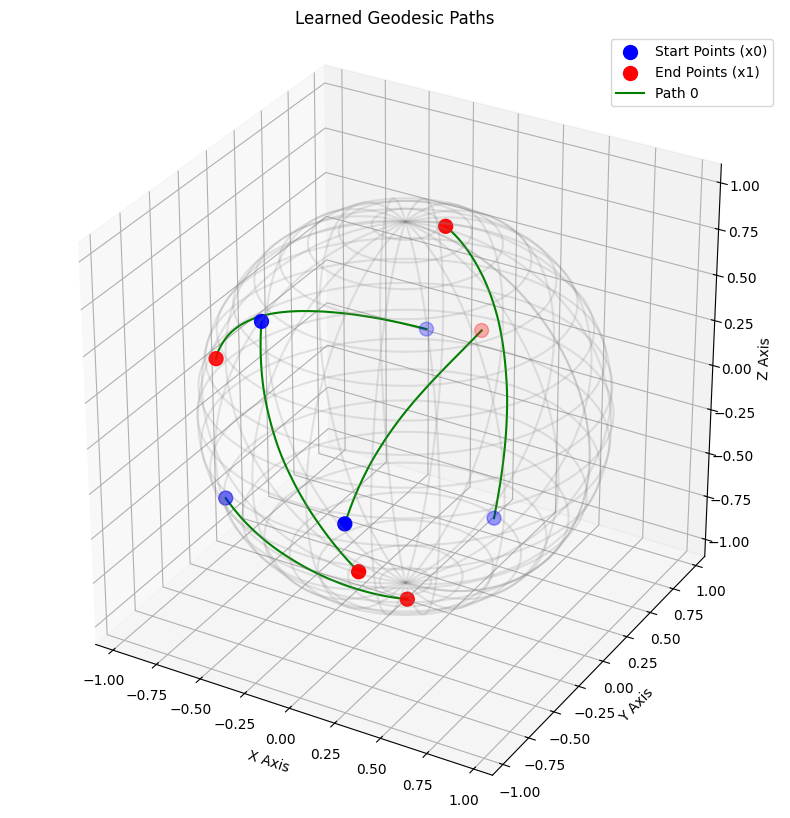

In [43]:
if d == 3:
    # --- Visualize ---
    visualize_geodesics(x0[:5], x1[:5], geodesic_paths[:5], "True")
    visualize_geodesics(x0[:5], x1[:5], [paths[:,i] for i in range(5)], "Learned")

In [44]:
paths.shape

torch.Size([100, 500, 3])

In [45]:
p = geodesic_paths[0]
print(torch.norm(p, dim = 1))

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000], dtype=torch.float64)


In [46]:
p = paths[:,3]
print(torch.norm(p, dim = 1))

tensor([1.0000, 0.9970, 0.9940, 0.9912, 0.9884, 0.9857, 0.9831, 0.9806, 0.9781,
        0.9758, 0.9735, 0.9712, 0.9690, 0.9668, 0.9647, 0.9627, 0.9607, 0.9588,
        0.9569, 0.9551, 0.9534, 0.9518, 0.9502, 0.9486, 0.9470, 0.9455, 0.9440,
        0.9425, 0.9411, 0.9397, 0.9383, 0.9370, 0.9358, 0.9347, 0.9336, 0.9327,
        0.9317, 0.9309, 0.9301, 0.9294, 0.9288, 0.9282, 0.9276, 0.9271, 0.9266,
        0.9261, 0.9258, 0.9256, 0.9252, 0.9248, 0.9245, 0.9243, 0.9241, 0.9240,
        0.9240, 0.9242, 0.9245, 0.9249, 0.9253, 0.9258, 0.9263, 0.9270, 0.9276,
        0.9283, 0.9292, 0.9302, 0.9313, 0.9325, 0.9336, 0.9349, 0.9362, 0.9375,
        0.9390, 0.9405, 0.9421, 0.9438, 0.9456, 0.9475, 0.9493, 0.9511, 0.9531,
        0.9551, 0.9571, 0.9593, 0.9615, 0.9639, 0.9662, 0.9687, 0.9711, 0.9735,
        0.9760, 0.9786, 0.9811, 0.9837, 0.9864, 0.9891, 0.9918, 0.9945, 0.9972,
        1.0000], dtype=torch.float64)


In [47]:
paths[0].shape

torch.Size([500, 3])

In [48]:
def geodesic_disc(paths, true_paths):
    assert paths.shape == true_paths.shape
    assert torch.allclose(torch.linalg.norm(paths[0], dim = 1).float(), torch.ones(paths.shape[1]))
    assert torch.allclose(torch.linalg.norm(paths[-1], dim = 1).float(), torch.ones(paths.shape[1]))
    z = torch.linalg.norm(paths-true_paths, dim = 2).mean(0)
    return z.mean(), z.std()

In [49]:
geodesic_disc(paths, torch.stack(geodesic_paths, dim=1))

(tensor(0.1329, dtype=torch.float64), tensor(0.1245, dtype=torch.float64))

Average geodesic error:

Sphere dim=10

MFM (K=2000): .20 \pm .08

EGGFM: 0.12 \pm .07

sphere dim=20

MFM (K=2000): .19 \pm .05

EGGFM: .16 \pm .05


In [50]:
####################

In [51]:
# import matplotlib.pyplot as plt

# categories = ["EGGFM", "MFM"]
# means = [.12, .20]
# stds = [.07, .08]

# plt.figure(figsize=(8, 6))
# plt.bar(categories, means, yerr=stds, capsize=5)
# plt.xlabel('Metrics')
# plt.ylabel('Average Geodesic Error')
# plt.show()

In [52]:
# categories = ['EGGFM', 'MFM']
# values = [.14, .21]

# # Create the bar plot
# plt.bar(categories, values)

# # Add labels and title
# plt.xlabel('Metrics')
# plt.ylabel('Average Geodesic Error')

# # Display the plot
# plt.show()